In [1]:
import numpy as np
import pandas
import geopandas
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt
from time import time
from pprint import pprint
from shapely import affinity
from shapely.ops import unary_union
import os
thisyear = 2025
the_epsg = 3968   # Virginia 3968
equalareacrs = "EPSG:6933"
#acs_year = 2023
state_abbrev = 'VA'
state_num = 51

workdir = '/home/idies/workspace/21cc/raddick/virginia-election-2025/'
shapefile_dir = '/home/idies/workspace/21cc/Data/Census/Shapefiles/TIGER/{0:.0f}/'.format(thisyear)
#acs5_dir = '/home/idies/workspace/21cc/Data/Census/ACS5/{0:.0f}/data/'.format(acs_year)

results_file = workdir + 'virginia-election-results-2025.csv'
county_shapefile = shapefile_dir + 'tl_2025_us_county.shp'
print('ok')

ok


# Read shapefiles and election results

In [2]:
s = time()
print('reading shapefiles...')
county_gdf = geopandas.read_file(county_shapefile, encoding='utf-8')
virginia_gdf = county_gdf[county_gdf['STATEFP'] == '51']
virginia_gdf = virginia_gdf.to_crs(epsg=the_epsg)

print('\treading water shapefiles...')
water_gdf = geopandas.GeoDataFrame()

water_file_list = [shapefile_dir+'AREAWATER/'+state_abbrev.lower()+'/'+x for x in os.listdir(shapefile_dir+'AREAWATER/'+state_abbrev.lower()) if (x[-4:] == '.shp') and ('tl_{0:04d}_{1:02d}'.format(thisyear,state_num) in x)]
for i in range(0, len(water_file_list)):
    if (np.mod(i, 20) == 0):
        print('\t\treading water file {0:,.0f} of {1:,.0f}...'.format(i, len(water_file_list)))
    water_gdf_i = geopandas.read_file(water_file_list[i])
    water_gdf = pandas.concat((water_gdf, water_gdf_i), axis=0)
water_gdf.loc[:, 'INTPTLON'] = pandas.to_numeric(water_gdf['INTPTLON'], errors='coerce')
water_gdf.loc[:, 'INTPTLAT'] = pandas.to_numeric(water_gdf['INTPTLAT'], errors='coerce')
water_gdf = water_gdf.set_index('HYDROID')
water_gdf = water_gdf.to_crs(epsg=the_epsg)

# print('reading populations from ACS5 data...')
# estimates_df = pandas.read_csv(acs5_dir+'estimates.csv')
# estimates_df.loc[:, 'B01001_001E'] = pandas.to_numeric(estimates_df['B01001_001E'])
# virginia_tracts_df = estimates_df[estimates_df['state'] == 51]
# county_pop_2023_df = pandas.DataFrame(data=virginia_tracts_df.groupby('county', as_index=False)['B01001_001E'].sum(), columns=['county', 'B01001_001E'])
# county_pop_2023_df = county_pop_2023_df.rename(columns={'B01001_001E': 'pop_2023'})

print('reading election results...')
results_df = pandas.read_csv(results_file)

print('\tconverting vote numbers to numeric...')
for col in ['Winsome-Sears', 'Spanberger', 'Others', 'Total votes']:    
    results_df.loc[:, col] = results_df[col].apply(lambda x: str(x).replace(',',''))
    results_df.loc[:, col] = pandas.to_numeric(results_df[col])

print('\tpicking winners...')
results_df = results_df.assign(ws_win = False)
results_df.loc[results_df.apply(lambda row: row['Winsome-Sears'] > row['Spanberger'], axis=1), 'ws_win'] = True
results_df = results_df.assign(span_win = False)
results_df.loc[results_df.apply(lambda row: row['Spanberger'] > row['Winsome-Sears'], axis=1), 'span_win'] = True

print('backing up...')
virginia_gdf_bk = virginia_gdf
results_df_bk = results_df
water_gdf_bk = water_gdf

e = time()


print('Read election results from {0:,.0f} counties+cities in {1:.1f} seconds!'.format(len(results_df), e-s))


reading shapefiles...
	reading water shapefiles...
		reading water file 0 of 133...
		reading water file 20 of 133...
		reading water file 40 of 133...
		reading water file 60 of 133...
		reading water file 80 of 133...
		reading water file 100 of 133...
		reading water file 120 of 133...
reading election results...
	converting vote numbers to numeric...
	picking winners...
backing up...
Read election results from 133 counties+cities in 12.3 seconds!


In [3]:
print('trimming oceans...')
virginia_gdf = virginia_gdf_bk
water_gdf = water_gdf_bk
#water_gdf = water_gdf.assign(area = water_gdf.geometry.area / (1000*1000))
#water_gdf.sort_values(by='area', ascending=False)[['FULLNAME', 'area']].head(20)

oceany_bodies_list = ['Atlantic Ocean', 'Chesapeake Bay']#, 'Pocomoke Sound', 'Tangier Sound', 'Hog Island Bay', 'Back Bay']
oceany_gdf = water_gdf[water_gdf['FULLNAME'].isin(oceany_bodies_list)]
oceany_geo = unary_union(oceany_gdf.geometry.values.tolist())
oceany_geo

cnt = 0
#geopandas.overlay(virginia_gdf, oceany_gdf, how='difference').plot()
for ix, thisrow in virginia_gdf.iterrows():
    if (np.mod(cnt, 20) == 0):
        print('trimming county/city number {0:,.0f}...'.format(cnt))
    if thisrow.geometry.intersects(oceany_geo):
        virginia_gdf.loc[ix, 'geometry'] = thisrow.geometry.difference(oceany_geo)
    cnt += 1
print('Done')

trimming oceans...
trimming county/city number 0...
trimming county/city number 20...
trimming county/city number 40...
trimming county/city number 60...
trimming county/city number 80...
trimming county/city number 100...
trimming county/city number 120...
Done


In [4]:
# print('getting from backup...')
# virginia_gdf = virginia_gdf_bk
# results_df = results_df_bk
s = time()
print('Election results have {0:,.0f} counties+cities'.format(len(results_df)))
print('Shapefiles have {0:,.0f} counties+cities'.format(len(virginia_gdf)))
print('Matching results to shapefiles...')
match_by_name_df = results_df.merge(virginia_gdf[['GEOID', 'NAME', 'NAMELSAD', 'geometry']], how='left', left_on='Locality', right_on='NAME')
#pprint(match_by_name_df[match_by_name_df['NAMELSAD'].isnull()])
match_by_name_df = match_by_name_df[match_by_name_df['NAMELSAD'].notnull()]
#print(len(match_by_name_df))

virginia_gdf = virginia_gdf.assign(name_city_caplitalized = virginia_gdf['NAMELSAD'].apply(lambda x: x.replace("city", "City")))
match_by_namelsad_df = results_df.merge(virginia_gdf[['GEOID', 'NAME', 'NAMELSAD', 'geometry', 'name_city_caplitalized']], how='left', left_on='Locality', right_on='name_city_caplitalized')
match_by_namelsad_df = match_by_namelsad_df[match_by_namelsad_df['NAME'].notnull()]
#print(len(match_by_namelsad_df))
virginia_gdf = virginia_gdf.drop('name_city_caplitalized', axis=1)
match_df = pandas.concat((match_by_name_df, match_by_namelsad_df), axis=0)

data_gdf = geopandas.GeoDataFrame(match_df)
#data_gdf = data_gdf.drop('name_city_capitalized', axis=1)
#data_gdf = data_gdf.to_crs(the_epsg)

# print('backing up...')
# data_gdf_bk = data_gdf
e = time()
print('Matched shapefiles for {0:,.0f} counties+cities in {1:.1f} seconds!'.format(len(results_df), e-s))


Election results have 133 counties+cities
Shapefiles have 133 counties+cities
Matching results to shapefiles...
Matched shapefiles for 133 counties+cities in 0.1 seconds!


plotting election results...


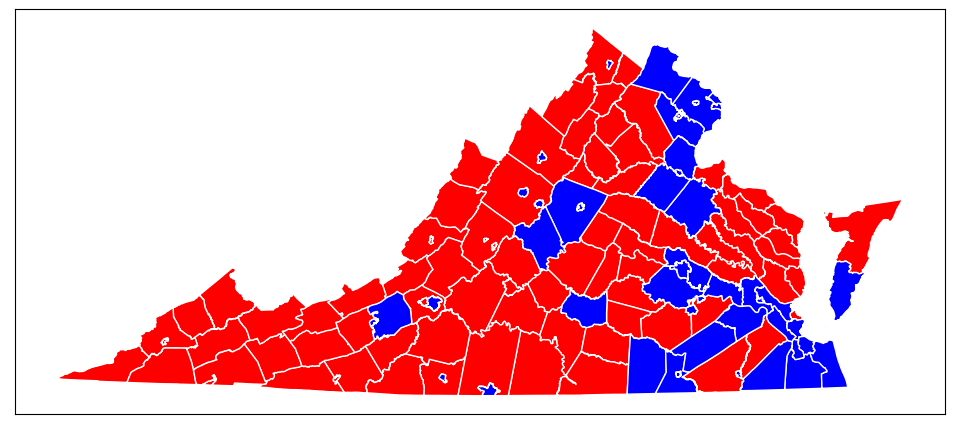

saving figure
ok


In [6]:
# print('getting from backup...')
# data_gdf = data_gdf_bk
fig, ax = plt.subplots(1,1, figsize=(12,8))
print('plotting election results...')
data_gdf[data_gdf['ws_win'] == True].plot(ax=ax, color='red', edgecolor='white')
data_gdf[data_gdf['span_win'] == True].plot(ax=ax, color='blue', edgecolor='white')
# for ix, thisrow in data_gdf[data_gdf['NAMELSAD'].isnull()].iterrows():
#     annotation = thisrow['Locality']
#     print(annotation)
# print('plotting water areas...')
# water_gdf.plot(ax=ax, color='white')
ax.set_xticks([])
ax.set_yticks([])

plt.show()
print('saving figure')
fig.savefig('virginia-election-2025-unscaled.svg', format='svg')
print('ok')

In [8]:
# Scale
# print('getting from backup...')
# data_gdf = data_gdf_bk

print('scaling...')
mean_votes = data_gdf['Total votes'].mean()
data_gdf = data_gdf.assign(scale_factor = data_gdf['Total votes'] * (mean_votes / data_gdf.to_crs(equalareacrs).geometry.area))
data_gdf = data_gdf.assign(new_geometry = data_gdf.apply(lambda row: affinity.scale(row['geometry'], row['scale_factor'], row['scale_factor']), axis=1))
data_gdf = data_gdf.set_geometry(data_gdf['new_geometry'])
print('Done!')

scaling...
Done!


# ALL

saving figure
ok


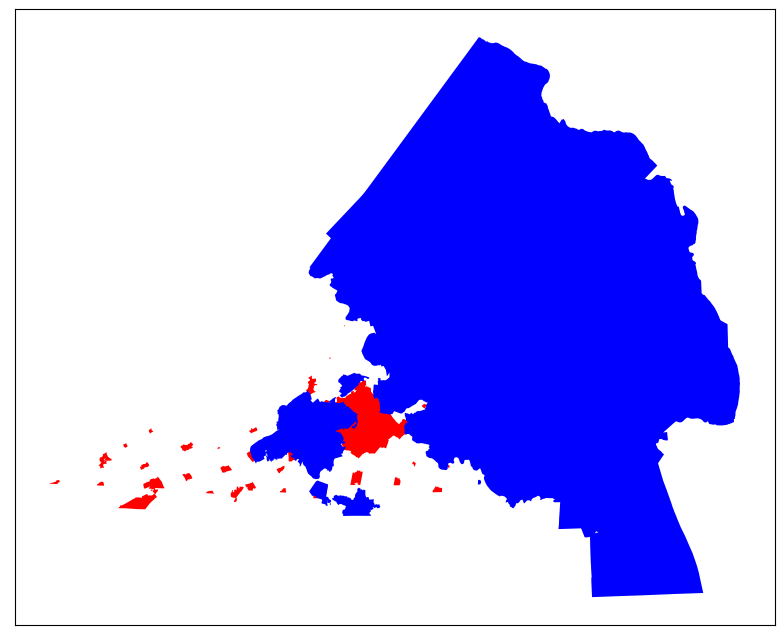

In [9]:
saveit = True
fig, ax = plt.subplots(1,1, figsize=(12,8))
data_gdf[(data_gdf['ws_win'] == True)].plot(ax=ax, color='red')
data_gdf[(data_gdf['span_win'] == True)].plot(ax=ax, color='blue')
ax.set_xticks([])
ax.set_yticks([])

if (saveit):
    print('saving figure')
    plt.savefig('virginia-election-2025-rescaled.svg', format='svg')
else:
    plt.show()
print('ok')
#data_gdf[data_gdf['NAMELSAD'].isin(county_list)]

# Northern Virginia

In [ ]:
# saveit = True
# county_list = ['Arlington County', 'Alexandria city', 'Falls Church city', 'Fairfax city', 'Fairfax County']
# county_list += ['Loudoun County', 'Prince William County', 'Manassas city', 'Manassas Park city']

# fig, ax = plt.subplots(1,1, figsize=(12,8))
# data_gdf[(data_gdf['NAMELSAD'].isin(county_list)) & (data_gdf['ws_win'] == True)].plot(ax=ax, color='red')
# data_gdf[(data_gdf['NAMELSAD'].isin(county_list)) & (data_gdf['span_win'] == True)].plot(ax=ax, color='blue')
# ax.set_xticks([])
# ax.set_yticks([])

# if (saveit):
#     print('saving figure')
#     plt.savefig('virginia-election-2025-rescaled-north.svg', format='svg')
# else:
#     plt.show()
# print('ok')
# #data_gdf[data_gdf['NAMELSAD'].isin(county_list)]

# Rest of Virginia

In [ ]:
# saveit = True

# county_list = ['Arlington County', 'Alexandria city', 'Falls Church city', 'Fairfax city', 'Fairfax County']
# county_list += ['Loudoun County', 'Prince William County', 'Manassas city', 'Manassas Park city', 'Falls Church city']
# county_list += ['Virginia Beach city', 'Chesapeake City']
# county_list += ['Chesterfield County']

# fig, ax = plt.subplots(1,1, figsize=(12,8))
# data_gdf[(~data_gdf['NAMELSAD'].isin(county_list)) & (data_gdf['ws_win'] == True)].plot(ax=ax, color='red')
# data_gdf[(~data_gdf['NAMELSAD'].isin(county_list)) & (data_gdf['span_win'] == True)].plot(ax=ax, color='blue')
# ax.set_xticks([])
# ax.set_yticks([])

# if (saveit):
#     print('saving figure')
#     plt.savefig('virginia-election-2025-rescaled-rest.svg', format='svg')
# else:
#     plt.show()
# print('ok')
# #data_gdf[data_gdf['NAMELSAD'].isin(county_list)]

In [ ]:
# Identify Counties we missed

In [ ]:
# saveit = True

# fig, ax = plt.subplots(1,1, figsize=(12,8))
# data_gdf[(~data_gdf['NAMELSAD'].isin(county_list)) & (data_gdf['ws_win'] == True)].plot(ax=ax, color='red')
# data_gdf[(~data_gdf['NAMELSAD'].isin(county_list)) & (data_gdf['span_win'] == True)].plot(ax=ax, color='blue')
# ax.set_xticks([])
# ax.set_yticks([])

# if (saveit):
#     print('saving figure')
#     plt.savefig('virginia-election-2025-rescaled-rest.svg', format='svg')
# else:
#     plt.show()
# print('ok')
# #data_gdf[data_gdf['NAMELSAD'].isin(county_list)]